# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SafeeAkmal/FlyRank-ML-internship-tasks/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

I am going to work with Lane 4: CTR/Engagement oppurtunity scoring. The question to answer is that which visible pages under-capture clicks or engagement and deserve metadata, content, or monitoring review? The reason for selecting this lane is to work more directly with specific features that impact the decision to work on which content page.

Total potential clicks captured if underperforming pages reached median CTR: 3,842,932
The top 100 opportunity pages account for 25.9% of all lost engagement.


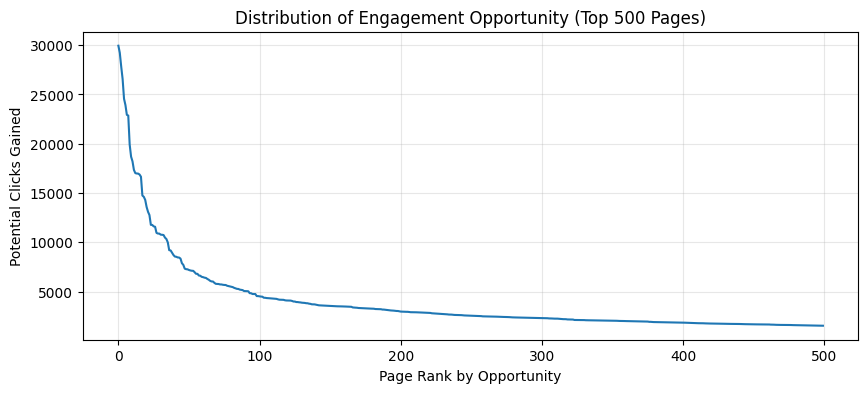

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Calculate a 'Market Average' CTR as a baseline for opportunity
median_ctr = df[df['impressions_90d'] > 100]['ctr'].median()

# Opportunity Score: How many clicks are we 'missing' if this page performed at least at the median?
df['engagement_gap'] = (median_ctr - df['ctr']) * df['impressions_90d']
# Focus only on where we are underperforming (gap > 0)
df['opportunity_score'] = df['engagement_gap'].clip(lower=0)

# Calculate total 'Lost Clicks' in the dataset
total_lost_clicks = df['opportunity_score'].sum()
top_100_lost_clicks = df.sort_values('opportunity_score', ascending=False).head(100)['opportunity_score'].sum()

print(f"Total potential clicks captured if underperforming pages reached median CTR: {total_lost_clicks:,.0f}")
print(f"The top 100 opportunity pages account for {(top_100_lost_clicks/total_lost_clicks)*100:.1f}% of all lost engagement.")

# Visual proof: The 'Long Tail' of underperformance
plt.figure(figsize=(10, 4))
df.sort_values('opportunity_score', ascending=False)['opportunity_score'].reset_index(drop=True).head(500).plot()
plt.title('Distribution of Engagement Opportunity (Top 500 Pages)')
plt.ylabel('Potential Clicks Gained')
plt.xlabel('Page Rank by Opportunity')
plt.grid(True, alpha=0.3)
plt.show()

## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

My work helps reviewers in identifying which pages should be required to review based on different metrics, so that the review phase passes quickly and the pages that need fixing get fixed at a faster rate. A wrong recommendation may cause the reviwer to work on content that might already be fine and can waste time and cost on reviewing a piece of content which shouldn't be required to review.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import numpy as np

# Define a 'Wrong Call' (False Positive): Reviewing a top-performer
top_performers = df[df['ctr'] > df['ctr'].quantile(0.75)]
avg_impressions_top = top_performers['impressions_90d'].mean()

# Define the 'Opportunity Cost' (False Negative): Missing a high-visibility underperformer
underperformers = df[(df['ctr'] < median_ctr) & (df['impressions_90d'] > df['impressions_90d'].quantile(0.90))]
lost_clicks_potential = underperformers['opportunity_score'].sum()

print(f" Cost of a Wrong Call ")
print(f"False Positive Cost: Reviewing 1 high-performer wastes attention on ~{avg_impressions_top:,.0f} impressions that don't need help.")
print(f"False Negative Cost: Ignoring the top 10% high-visibility underperformers costs ~{lost_clicks_potential:,.0f} potential clicks.")

# Display a sample of high-opportunity pages that need review
display(underperformers[['content_id', 'impressions_90d', 'ctr', 'opportunity_score']].sort_values('opportunity_score', ascending=False).head(5))

 Cost of a Wrong Call 
False Positive Cost: Reviewing 1 high-performer wastes attention on ~7,822 impressions that don't need help.
False Negative Cost: Ignoring the top 10% high-visibility underperformers costs ~2,349,236 potential clicks.


,content_id,impressions_90d,ctr,opportunity_score
7678,content_8451fc6f034d,272144,0.03,29935.84
7445,content_c8e9d6ab9013,208678,0.00,29214.92
15405,content_a023517539fe,214047,0.01,27826.11
3394,content_36ff89c8214e,295097,0.05,26558.73
6903,content_c84a0ab98e90,223271,0.03,24559.81


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

# Metric 1: Count of high-visibility pages with sub-median CTR
high_vis_threshold = df['impressions_90d'].quantile(0.75)
underperforming_high_vis = df[(df['impressions_90d'] > high_vis_threshold) & (df['ctr'] < median_ctr)]
count_uv = len(underperforming_high_vis)

# Metric 2: Concentration of opportunity (Top 1% of pages)
top_1_percent_count = int(len(df) * 0.01)
top_1_percent_opp = df.sort_values('opportunity_score', ascending=False).head(top_1_percent_count)['opportunity_score'].sum()
perc_opp = (top_1_percent_opp / total_lost_clicks) * 100

# Metric 3: Average impressions at risk per high-opportunity page
avg_imp_at_risk = underperforming_high_vis['impressions_90d'].mean()

print(f"1. High-Visibility Underperformers: {count_uv} pages have high reach but below-median CTR.")
print(f"2. Opportunity Concentration: The top 1% of opportunity pages account for {perc_opp:.1f}% of all lost clicks.")
print(f"3. Wasted Potential: Each priority candidate for review averages ~{avg_imp_at_risk:,.0f} impressions every 90 days.")


1. High-Visibility Underperformers: 2483 pages have high reach but below-median CTR.
2. Opportunity Concentration: The top 1% of opportunity pages account for 42.2% of all lost clicks.
3. Wasted Potential: Each priority candidate for review averages ~17,837 impressions every 90 days.


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*
My work will be able to explain what was observed and will be able to support the stakeholders in decision making. It will never give a sure short answer that would be 100% correct like predicting Google, rather it will show the observations that matter and will suggest tips to improve the content.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Observed: Overlap between Opportunity Score and Content Decline
df['is_declining'] = df['trend_direction'].str.lower().eq('down')

# Compare top opportunity pages vs the rest
top_opp_threshold = df['opportunity_score'].quantile(0.95)
high_opp_df = df[df['opportunity_score'] > top_opp_threshold]
rest_df = df[df['opportunity_score'] <= top_opp_threshold]

print(f"Observed: {high_opp_df['is_declining'].mean()*100:.1f}% of high-opportunity pages are currently in decline.")
print(f"Directional: High-opportunity pages are {high_opp_df['is_declining'].mean() / rest_df['is_declining'].mean():.1f}x more likely to be trending 'Down'.")
print("\nDecision Support: This score identifies candidates for review, but it does NOT claim")
print("that fixing metadata will automatically reverse a Google ranking trend.")

Observed: 67.3% of high-opportunity pages are currently in decline.
Directional: High-opportunity pages are 1.3x more likely to be trending 'Down'.

Decision Support: This score identifies candidates for review, but it does NOT claim
that fixing metadata will automatically reverse a Google ranking trend.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.